# 01_Predictive_AI_Titanic_Classification

## Workshop: From Predictive to Generative AI

### Learning Objectives:
- Understand the traditional ML pipeline: Load → Clean → Train → Predict
- Experience how Predictive AI works with structured data
- Recognize the limitation: can only predict known categories (0 or 1)

### The Challenge:
Can we predict who survived the Titanic disaster based on passenger information?

## Step 1: Load Required Libraries and Data

First, we install and import the tools we need for our predictive model.

In [1]:
# Install required libraries (run this first in Google Colab)
!pip install pandas scikit-learn seaborn matplotlib

# Import essential libraries for data science
import pandas as pd                    # For data manipulation
import numpy as np                     # For numerical operations
from sklearn.model_selection import train_test_split  # Split data for training/testing
from sklearn.linear_model import LogisticRegression   # Our prediction algorithm
from sklearn.metrics import accuracy_score, classification_report  # Measure performance
import seaborn as sns                  # For beautiful visualizations
import matplotlib.pyplot as plt       # For plotting graphs

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [14]:
# Load the Titanic dataset from a public URL
# This dataset contains information about Titanic passengers
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_data = pd.read_csv(url)

print(f"📊 Dataset loaded! Shape: {titanic_data.shape}")
print(f"   - {titanic_data.shape[0]} passengers")
print(f"   - {titanic_data.shape[1]} features per passenger")

# Let's peek at the first few rows
print("\n🔍 First 5 passengers:")
titanic_data.head()

📊 Dataset loaded! Shape: (891, 12)
   - 891 passengers
   - 12 features per passenger

🔍 First 5 passengers:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 2: Clean the Data (Simple Preprocessing)

Real-world data is messy! We need to clean it before our algorithm can learn from it.

🔍 Missing data check:
Age         177
Cabin       687
Embarked      2
dtype: int64


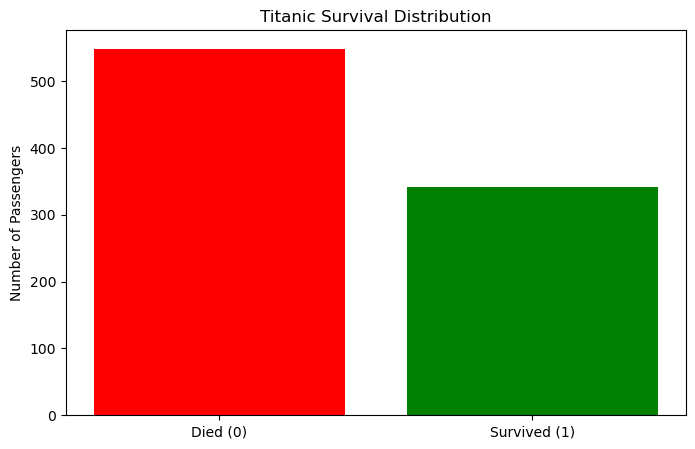


📈 Survival Rate: 38.4%


In [15]:
# Check for missing data - this is crucial in real datasets
print("🔍 Missing data check:")
missing_data = titanic_data.isnull().sum()
print(missing_data[missing_data > 0])  # Only show columns with missing data

# Visualize survival rates to understand our target
plt.figure(figsize=(8, 5))
survival_counts = titanic_data['Survived'].value_counts()
plt.bar(['Died (0)', 'Survived (1)'], survival_counts.values, color=['red', 'green'])
plt.title('Titanic Survival Distribution')
plt.ylabel('Number of Passengers')
plt.show()

print(f"\n📈 Survival Rate: {titanic_data['Survived'].mean():.1%}")

In [16]:
# Simple data cleaning - keep only essential features
# We'll use features that are most likely to predict survival

# Select relevant columns for our prediction
features_to_use = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']
clean_data = titanic_data[features_to_use].copy()

# Handle missing values with simple strategies
# Age: Fill missing ages with the median (middle value)
# Use assignment instead of inplace to avoid pandas chained-assignment FutureWarning
clean_data['Age'] = clean_data['Age'].fillna(clean_data['Age'].median())

# Fare: Fill missing fares with the median
# Use assignment instead of inplace to avoid pandas chained-assignment FutureWarning
clean_data['Fare'] = clean_data['Fare'].fillna(clean_data['Fare'].median())

# Convert categorical 'Sex' to numbers (Male=1, Female=0)
# Computers need numbers, not text!
clean_data['Sex'] = clean_data['Sex'].map({'male': 1, 'female': 0})

print("✅ Data cleaning complete!")
print(f"   - No missing values: {clean_data.isnull().sum().sum() == 0}")
print(f"   - Final dataset shape: {clean_data.shape}")

# Show the cleaned data
clean_data.head()

✅ Data cleaning complete!
   - No missing values: True
   - Final dataset shape: (891, 7)


,Pclass,Sex,Age,SibSp,Parch,Fare,Survived
0,3,1,22.0,1,0,7.2500,0
1,1,0,38.0,1,0,71.2833,1
2,3,0,26.0,0,0,7.9250,1
3,1,0,35.0,1,0,53.1000,1
4,3,1,35.0,0,0,8.0500,0


## Step 3: Train the Predictive Model

Now we teach our algorithm to recognize patterns between passenger features and survival.

In [17]:
# Separate features (X) from target (y)
# Features: What we know about passengers (age, class, etc.)
# Target: What we want to predict (survived or not)

X = clean_data.drop('Survived', axis=1)  # All columns except 'Survived'
y = clean_data['Survived']               # Only the 'Survived' column

print(f"📊 Features (X): {X.shape} - What we know about passengers")
print(f"🎯 Target (y): {y.shape} - What we want to predict")
print(f"\n🔍 Feature columns: {list(X.columns)}")

📊 Features (X): (891, 6) - What we know about passengers
🎯 Target (y): (891,) - What we want to predict

🔍 Feature columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']


In [18]:
# Split data into training and testing sets
# Training set: Teach the algorithm (80% of data)
# Testing set: Test how well it learned (20% of data)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # Use 20% for testing
    random_state=42,    # For reproducible results
    stratify=y          # Keep same survival ratio in both sets
)

print(f"🎓 Training set: {X_train.shape[0]} passengers")
print(f"🧪 Testing set: {X_test.shape[0]} passengers")
print(f"\n📊 Training survival rate: {y_train.mean():.1%}")
print(f"📊 Testing survival rate: {y_test.mean():.1%}")

🎓 Training set: 712 passengers
🧪 Testing set: 179 passengers

📊 Training survival rate: 38.3%
📊 Testing survival rate: 38.5%


In [19]:
# Create and train the Logistic Regression model
# Logistic Regression: A simple but powerful algorithm for yes/no predictions

model = LogisticRegression(random_state=42, max_iter=1000)

# Train the model - this is where the "learning" happens!
print("🎓 Training the model...")
model.fit(X_train, y_train)
print("✅ Model training complete!")

# Test the model's performance
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"\n📈 Model Performance:")
print(f"   - Training Accuracy: {train_accuracy:.1%}")
print(f"   - Testing Accuracy: {test_accuracy:.1%}")

# Show detailed performance report
print("\n📊 Detailed Performance Report:")
print(classification_report(y_test, test_predictions, target_names=['Died', 'Survived']))

🎓 Training the model...


✅ Model training complete!

📈 Model Performance:
   - Training Accuracy: 79.2%
   - Testing Accuracy: 80.4%

📊 Detailed Performance Report:
              precision    recall  f1-score   support

        Died       0.83      0.86      0.84       110
    Survived       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



## Step 4: Predict New Data

Let's use our trained model to predict survival for new passengers!

In [20]:
# Create some new passenger profiles to test our model
# Each row represents a different passenger with their characteristics

new_passengers = pd.DataFrame({
    'Pclass': [1, 3, 2, 1, 3],           # Passenger class (1=First, 2=Second, 3=Third)
    'Sex': [0, 1, 0, 1, 0],              # Gender (0=Female, 1=Male)
    'Age': [25, 30, 45, 35, 20],         # Age in years
    'SibSp': [0, 1, 2, 0, 1],            # Number of siblings/spouses aboard
    'Parch': [0, 2, 1, 0, 0],            # Number of parents/children aboard
    'Fare': [100, 15, 50, 200, 10]      # Ticket fare
})

# Make predictions for these new passengers
survival_predictions = model.predict(new_passengers)
survival_probabilities = model.predict_proba(new_passengers)[:, 1]  # Probability of survival

# Create a readable results table
results = new_passengers.copy()
results['Sex_Label'] = results['Sex'].map({0: 'Female', 1: 'Male'})
results['Predicted_Survival'] = survival_predictions
results['Survival_Probability'] = survival_probabilities
results['Outcome'] = results['Predicted_Survival'].map({0: '💀 Died', 1: '✅ Survived'})

print("🔮 Predictions for New Passengers:")
print("=" * 80)

for i, row in results.iterrows():
    print(f"Passenger {i+1}: {row['Sex_Label']}, Age {row['Age']}, Class {row['Pclass']}")
    print(f"   → {row['Outcome']} (Probability: {row['Survival_Probability']:.1%})")
    print()

# Show the full results table
display_columns = ['Sex_Label', 'Age', 'Pclass', 'Fare', 'Outcome', 'Survival_Probability']
print("📊 Complete Results Table:")
results[display_columns]

🔮 Predictions for New Passengers:
Passenger 1: Female, Age 25, Class 1
   → ✅ Survived (Probability: 95.2%)

Passenger 2: Male, Age 30, Class 3
   → 💀 Died (Probability: 6.5%)

Passenger 3: Female, Age 45, Class 2
   → ✅ Survived (Probability: 59.0%)

Passenger 4: Male, Age 35, Class 1
   → ✅ Survived (Probability: 57.6%)

Passenger 5: Female, Age 20, Class 3
   → ✅ Survived (Probability: 62.5%)

📊 Complete Results Table:


,Sex_Label,Age,Pclass,Fare,Outcome,Survival_Probability
0,Female,25,1,100,✅ Survived,0.951671
1,Male,30,3,15,💀 Died,0.064776
2,Female,45,2,50,✅ Survived,0.589722
3,Male,35,1,200,✅ Survived,0.575570
4,Female,20,3,10,✅ Survived,0.625463


## Key Insight: The Limitation of Predictive AI

### 🎯 What We Just Accomplished:
- Built a model that can predict Titanic survival with ~80% accuracy
- Followed the classic ML pipeline: Load → Clean → Train → Predict
- Used historical data to make predictions about similar situations

### ⚠️ The Critical Limitation:
**This model can ONLY predict known categories: 0 (Died) or 1 (Survived)**

- It cannot generate new insights beyond these two options
- It cannot explain WHY someone survived in natural language
- It cannot create stories, images, or any creative content
- It's limited to the patterns it learned from historical data

### 🚀 What's Next?
In the next notebook, we'll explore **Generative AI** - models that can:
- Generate human-like text explanations
- Create content that never existed before
- Understand and respond to complex prompts
- Go beyond simple classification to true creativity!

---

**Remember**: Predictive AI is excellent for specific, well-defined problems with historical data. But when you need creativity, explanation, or generation of new content, that's where Generative AI shines! 🌟